In [105]:
library("DESeq2")
library("ggplot2")
library("ggrepel")
library("ggcorrplot")
library("dplyr")
library(stringr)
library(purrr)
library("tibble")
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library("pals")
library(ggpubr)
library(tximport)
library(DESeq2)
library("apeglm")
library(patchwork)
library(ggrastr)
library(circlize)
library(limma)
theme_set(
    theme_classic(base_size = 12)
)
source('./plot_data.R')

In [2]:
final_iso_tb<- read.table("../data/2_final_iso_tb.tsv", sep = "\t", header = T)
length(unique(final_iso_tb$gene_id))
dim(final_iso_tb)[1]


[1] 6016

[1] 6292

In [76]:
count_nascent<- read.table('../data/7_nascent_rna_count.tsv', sep = '\t', header = T)
# collapse long-read rna colnames(count_nascent) expression to gene expression table
count_nascent_with_antisense<- count_nascent %>%
    mutate(iso_id = str_split_i(rownames(count_nascent), "_", i = 1)) %>% 
    mutate(annot = str_split_i(iso_id, ":", i = 2)) %>% 
    mutate(gene_id = str_split_i(rownames(count_nascent), "_", i = -1)) %>% 
    group_by(gene_id)  %>% 
    summarise(across(1:4, sum)) %>% 
    column_to_rownames(var= "gene_id")

count_nascent_without_antisense<- count_nascent %>%
    mutate(iso_id = str_split_i(rownames(count_nascent), "_", i = 1)) %>% 
    mutate(annot = str_split_i(iso_id, ":", i = 2)) %>% 
    mutate(gene_id = str_split_i(rownames(count_nascent), "_", i = -1)) %>% 
    filter(is.na(annot)) %>% 
    group_by(gene_id)  %>% 
    summarise(across(1:4, sum)) %>% 
    column_to_rownames(var= "gene_id")

tpm_nascent_with_antisense<- countToTPM(count_nascent_with_antisense, normalize_by_len = FALSE)
tpm_nascent_without_antisense<- countToTPM(count_nascent_without_antisense, normalize_by_len = FALSE)

dim(tpm_nascent_with_antisense)
dim(tpm_nascent_without_antisense)

write.table(x = count_nascent_with_antisense, file = '../data/7_nascent_rna_gene_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_nascent_with_antisense, file = '../data/7_nascent_rna_gene_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

write.table(x = count_nascent_without_antisense, file = '../data/7_nascent_rna_no_antisense_gene_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_nascent_without_antisense, file = '../data/7_nascent_rna_no_antisense_gene_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

[1] 6512    4

[1] 6449    4

In [75]:
count_mature<- read.table('../data/7_mature_rna_count.tsv', sep = '\t', header = T)

# collapse long-read rna colnames(count_mature) expression to gene expression table
count_mature_with_antisense<- count_mature %>%
    mutate(iso_id = str_split_i(rownames(count_mature), "_", i = 1)) %>% 
    mutate(annot = str_split_i(iso_id, ":", i = 2)) %>% 
    mutate(gene_id = str_split_i(rownames(count_mature), "_", i = -1)) %>% 
    group_by(gene_id)  %>% 
    summarise(across(1:6, sum)) %>% 
    column_to_rownames(var= "gene_id")

count_mature_without_antisense<- count_mature %>%
    mutate(iso_id = str_split_i(rownames(count_mature), "_", i = 1)) %>% 
    mutate(annot = str_split_i(iso_id, ":", i = 2)) %>% 
    mutate(gene_id = str_split_i(rownames(count_mature), "_", i = -1)) %>% 
    filter(is.na(annot)) %>% 
    group_by(gene_id)  %>% 
    summarise(across(1:6, sum)) %>% 
    column_to_rownames(var= "gene_id")

tpm_mature_with_antisense<- countToTPM(count_mature_with_antisense, normalize_by_len = FALSE)
tpm_mature_without_antisense<- countToTPM(count_mature_without_antisense, normalize_by_len = FALSE)

dim(tpm_mature_with_antisense)
dim(tpm_mature_without_antisense)

write.table(x = count_mature_with_antisense, file = '../data/7_mature_rna_gene_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_mature_with_antisense, file = '../data/7_mature_rna_gene_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

write.table(x = count_mature_without_antisense, file = '../data/7_mature_rna_no_antisense_gene_count.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)
write.table(x = tpm_mature_without_antisense, file = '../data/7_mature_rna_no_antisense_gene_tpm.tsv', sep = "\t", quote = FALSE, col.names = TRUE, row.names = TRUE)

[1] 6524    6

[1] 6472    6

## pca between all three libraries

In [39]:
all_genes = sort(unique(final_iso_tb$gene_id))

In [74]:
tpm_totalrna<- read.table("../data/1_total_rna_rsem_iso_TPM.tsv", sep = "\t")
tpm_mature<- read.table("../data/7_mature_rna_no_antisense_gene_tpm.tsv", sep = "\t")
tpm_nascent<- read.table("../data/7_nascent_rna_no_antisense_gene_tpm.tsv", sep = "\t")

tpm_totalrna <- tpm_totalrna[all_genes, , drop = FALSE]
colnames(tpm_totalrna)<- paste0("Total-", rep(c("WT", "MUT"), each = 3), '-', rep(c("rep1", "rep2", "rep3"), 2))

tpm_mature <- tpm_mature[all_genes, , drop = FALSE]

colnames(tpm_mature)<- paste0("Mature-", rep(c("WT", "MUT"), each = 3), '-', rep(c("rep1", "rep2", "rep3"), 2))

tpm_nascent <- tpm_nascent[all_genes, , drop = FALSE]
colnames(tpm_nascent)<- paste0("Nascent-", rep(c("WT", "MUT"), each = 2), '-', rep(c("rep1", "rep2"), 2))

head(tpm_totalrna, 3)
head(tpm_mature, 3)
head(tpm_nascent, 3)

tpm<- cbind(tpm_totalrna, tpm_mature, tpm_nascent)
tpm[is.na(tpm)] <- 0
tpm =tpm[!rowSums(tpm) == 0, ]

,Total-WT-rep1,Total-WT-rep2,Total-WT-rep3,Total-MUT-rep1,Total-MUT-rep2,Total-MUT-rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAC1,0.96,1.45,1.56,0.67,0.91,1.12
AAC3,14.81,16.10,15.62,12.75,15.55,12.58
AAD10,4.39,3.48,4.29,5.20,5.82,6.41


,Mature-WT-rep1,Mature-WT-rep2,Mature-WT-rep3,Mature-MUT-rep1,Mature-MUT-rep2,Mature-MUT-rep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAC1,10.956613,5.694261,9.305187,10.49506,8.007468,6.300394
AAC3,34.622897,50.678927,37.802324,47.38681,52.927413,48.920705
AAD10,3.506116,1.708278,1.163148,14.31145,15.038416,15.195068


,Nascent-WT-rep1,Nascent-WT-rep2,Nascent-MUT-rep1,Nascent-MUT-rep2
,<dbl>,<dbl>,<dbl>,<dbl>
AAC1,13.49928,14.4111091,13.798173,7.151072
AAC3,78.86424,95.7914899,81.534658,82.562372
AAD10,0.00000,0.8477123,6.899086,9.751461


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


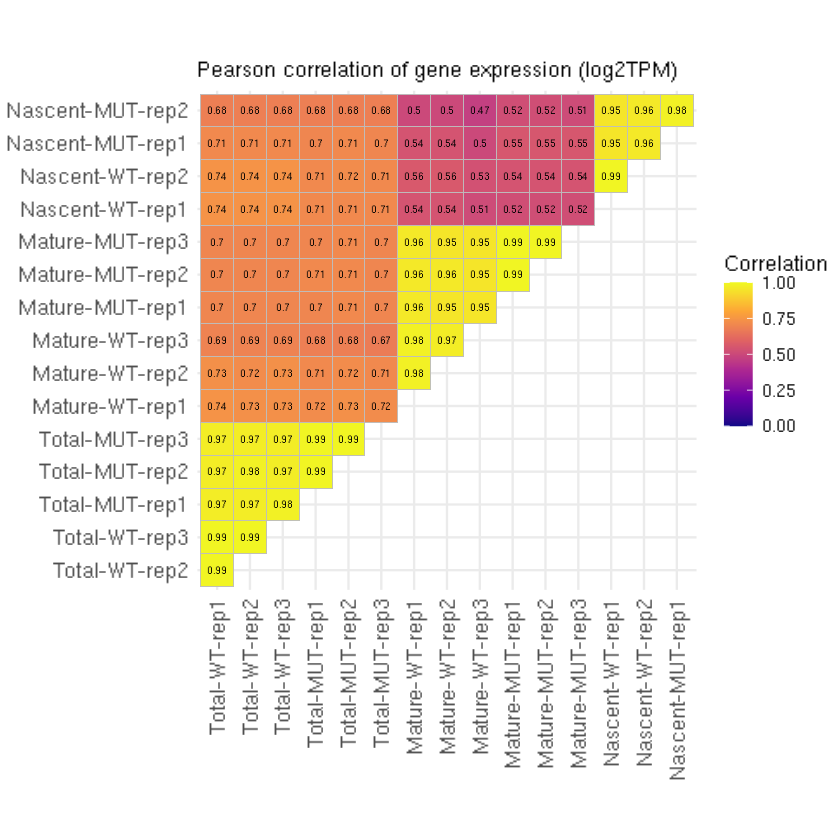

In [116]:
corr <- round(cor(log2(tpm+1), method =  'pearson'), 2)

ggcorrplot(corr, lab = TRUE, lab_col = "black", tl.cex = 12, lab_size = 2, type = "upper") +
    scale_fill_viridis_c(option = "plasma", limits = c(0, 1)) +
    labs(x = "", y = "", fill = "Correlation", title = 'Pearson correlation of gene expression (log2TPM)') +
    theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = .5),
          plot.title = element_text(size = 12),
          legend.title = element_text(size = 12),
          legend.text = element_text(size = 10))

ggsave('../figures/Supp_pearson_correlation_of_gene_expression_all_rna_library_no_antisense.pdf', width = 6, height = 6)

In [ ]:
gene_tb<- iso_tb %>% 
    filter(chrom != 'chrM', !geneid %in% sub_telo_genes) %>% 
    arrange(geneid, -isolen)

gene_tb = gene_tb[!duplicated(gene_tb$geneid), ]
rownames(gene_tb) = gene_tb$geneid

wt_tpm$genelen = gene_tb[rownames(wt_tpm), "isolen"]

wt_tpm %>% 
    ggplot(aes(x = Illumina, y = Nascent, color = log10(genelen))) +
    geom_point(size = 0.5, alpha = 0.8) +
    scale_color_viridis(option = "plasma", name = "log10(gene length)") +
    theme_bw(base_size = 12) +
    labs(x = "Illumina (Log2TPM)", y = "Nascent (Log2TPM)", title = "Average expression in WT") +
    annotate("text", x = 11, y = 16, label = paste0("\nR² = ", r2), hjust = 0, size = 5) +
    geom_text_repel(data = up_genes,
                    aes(label = rownames(up_genes)),
                    size = 3, color = "black") +
    geom_text_repel(data = down_genes,
                    aes(label = rownames(down_genes)),
                    size = 3, color = "black")

ggsave("../figures/250926_pearson_correlation_illumina_vs_nascent_by_genelen.pdf", width = 6, height = 4)

## mature rna DE gene analysis

In [127]:
count<- read.table('../data/7_mature_rna_gene_count.tsv')
tpm<- read.table('../data/7_mature_rna_gene_tpm.tsv')


smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]


coldata = data.frame(condition = str_split_i(colnames(count), "\\.", 1), batch = rep(1, ncol(count)))
coldata

rownames(coldata) = colnames(count)

library("DESeq2")
dds <- DESeqDataSetFromMatrix(countData = count,
                              colData = coldata,
                              design = ~ condition)
dds
dds$condition <- relevel(dds$condition, ref = "WT")

dds <- DESeq(dds)
res <- results(dds)
vsd <- vst(dds)
resLFC <- lfcShrink(dds, coef="condition_MUT_vs_WT", type="apeglm")
de_mature_rna<- analyzeDESeq_gene(res, resLFC, final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)
write.table(x = de_mature_rna, file = '../data/7_mature_rna_gene_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)

.
FALSE  TRUE 
  993  5531 

condition,batch
<chr>,<dbl>
WT,1
WT,1
WT,1
MUT,1
MUT,1
MUT,1


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”


class: DESeqDataSet 
dim: 5531 6 
metadata(1): version
assays(1): counts
rownames(5531): AAC1 AAC3 ... snR87 snR9
rowData names(0):
colnames(6): WT.rep1 WT.rep2 ... MUT.rep2 MUT.rep3
colData names(2): condition batch

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



.
FALSE  TRUE 
  841  5671 

,groupMUT,groupWT
AAC1,3.543279,3.94199092
AAC3,6.340815,6.44866876
AAD10,3.549815,0.08723255
AAD14,5.646586,4.60960257
AAD16,4.302005,-0.30178501
AAD3,3.509429,0.32429500


,groupMUT - groupWT
groupMUT,1
groupWT,-1


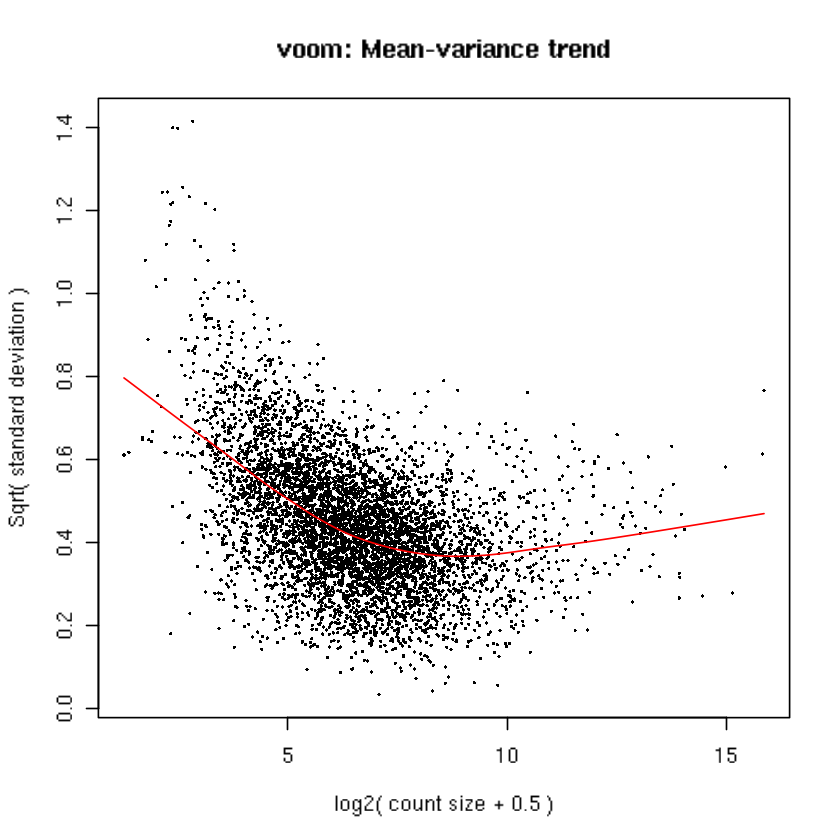

In [130]:
count<- read.table('../data/7_nascent_rna_gene_count.tsv')
tpm<- read.table('../data/7_nascent_rna_gene_tpm.tsv')

smallestGroupSize = 2
smallestCount = 10
keep <- rowSums(count >= smallestCount) >= smallestGroupSize
keep %>% table()
count<- count[keep, ]
tpm<- tpm[keep, ]

group<- c("WT", "WT", "MUT", "MUT")
mm <- model.matrix(~0 + group)
y <- voom(count, mm, plot = T)

fit <- lmFit(y, mm)
head(coef(fit))

contr <- makeContrasts(groupMUT - groupWT, levels = colnames(coef(fit)))
contr

tmp <- contrasts.fit(fit, contr)
tmp <- eBayes(tmp)

topTable <- topTable(tmp, sort.by = "P", n = Inf)


de_df<- cbind(WT = rowMeans(tpm[, c(1:2)]), MUT = rowMeans(tpm[,c(3,4)])) %>% as.data.frame()
de_df$log2FoldChange = topTable[match(rownames(de_df), rownames(topTable)), "logFC"]
de_df$padj = topTable[match(rownames(de_df), rownames(topTable)), "adj.P.Val"]

de_df = analyzeDESeq_gene(res = de_df, genelist = final_iso_tb$gene_id, padj_cutoff = 0.05, log2fc_cutoff = 0.5, annot_down = 3, annot_up = 3)

write.table(x = de_df, file = '../data/7_nascent_rna_gene_DE_results.tsv', quote = F, sep = '\t', col.names = T, row.names = T)